In [ ]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="7"

In [5]:
import torch
import numpy as np

In [6]:
t = torch.tensor([0], device="cuda")

In [7]:
from aidan_lib.models.sam3_multiplex import SAM3Harness

/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [8]:
# harness = SAM3Harness()

In [9]:
from pathlib import Path
import cv2
import imageio
from PIL import Image

In [ ]:
from aidan_lib.definitions import DATA_DIR
test_vid_path = DATA_DIR / "tip_to_tip_short.mp4"
assert test_vid_path.exists(), f"Test video does not exist {test_vid_path.absolute().as_posix()}"

In [11]:
from aidan_lib.video_utils.load_batched_frames import load_batched_frames, load_constrained_batched_frames
from aidan_lib.video_utils.scene_split import get_constrained_scenes, get_transnet_model

In [12]:
import time
start_time = time.perf_counter()
total_frames = 0
for frame_batch, frame_num_batch in load_batched_frames(test_vid_path, skip_frames=5, convert_pil=True):
    print(len(frame_num_batch))
    total_frames += len(frame_batch)
end_time = time.perf_counter()
total_time = end_time - start_time

print(f"Took {total_time:.2f} to load {total_frames} frames. {total_frames / total_time:.2f} fps")

120
120
81
Took 5.33 to load 321 frames. 60.19 fps


In [13]:
transnet = get_transnet_model("cuda")
constrained_scenes = get_constrained_scenes(test_vid_path, transnet, threshold=0.75)

/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/transnetv2_pytorch/transnetv2_pytorch.py:706: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context

In [14]:
constrained_scenes

[{'shot_id': 1,
  'start_frame': 0,
  'end_frame': 163,
  'start_time': 0.0,
  'end_time': 5.440806246172689,
  'probability': 0.9357414841651917},
 {'shot_id': 2,
  'start_frame': 164,
  'end_frame': 302,
  'start_time': 5.474185425597061,
  'end_time': 10.08051218616044,
  'probability': 0.9558759927749634},
 {'shot_id': 3,
  'start_frame': 303,
  'end_frame': 490,
  'start_time': 10.113891365584813,
  'end_time': 16.355797917942436,
  'probability': 0.9887474775314331},
 {'shot_id': 4,
  'start_frame': 491,
  'end_frame': 716,
  'start_time': 16.389177097366808,
  'end_time': 23.899492467850582,
  'probability': 0.9457775354385376},
 {'shot_id': 5,
  'start_frame': 717,
  'end_frame': 1085,
  'start_time': 23.932871647274954,
  'end_time': 36.21640967544397,
  'probability': 0.9253305196762085},
 {'shot_id': 6,
  'start_frame': 1086,
  'end_frame': 1148,
  'start_time': 36.24978885486834,
  'end_time': 38.319297979179424,
  'probability': 0.8632628321647644},
 {'shot_id': 7,
  'star

In [15]:
for frame_batch, frame_num_batch, is_scene_end in load_constrained_batched_frames(test_vid_path, constrained_scenes, batch_size=120, skip_frames=None, convert_pil=False):
    print(is_scene_end, len(frame_num_batch), frame_num_batch)

False 82 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81]
True 82 [82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163]
False 70 [164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 2

In [36]:
test_split_dir_path = test_vid_path.parent / f"{test_vid_path.stem}"
test_split_dir_path.mkdir(exist_ok=True)

for scene_num, (frame_batch, frame_num_batch, is_scene_end) in enumerate(load_constrained_batched_frames(test_vid_path, constrained_scenes, batch_size=120, skip_frames=3, convert_pil=False, overlap=1)):
    file_name = f"batch_{scene_num}"
    if is_scene_end:
        file_name += "_scene_end"
    print(f"Writing batch {file_name}")
    scene_path = test_split_dir_path / f"{file_name}.mp4"
    filename = scene_path.absolute().as_posix()

    writer = imageio.get_writer(filename, fps=29.97, codec='libx264')

    frame_batch = np.array(frame_batch)
    frame_batch = frame_batch[:, :, :, [2, 1, 0]]
    writer.append_data(frame_batch)
    
    writer.close()


Writing batch batch_0_scene_end
Writing batch batch_1_scene_end
Writing batch batch_2_scene_end
Writing batch batch_3_scene_end
Writing batch batch_4
Writing batch batch_5_scene_end
Writing batch batch_6_scene_end
Writing batch batch_7
Writing batch batch_8_scene_end


In [16]:
harness = SAM3Harness()

Constructing multiplex predictor
dynamic_multimask_via_stability is reset to False in the multiplex model


INFO 2026-04-30 17:50:06,688 1177846 sam3_multiplex_base.py: 336: `setting max_num_objects` to 16 -- creating num_obj_for_compile=1 objects for torch.compile cache


Missing keys (64): ['detector.backbone.vision_backbone.trunk.blocks.0.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.0.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.1.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.1.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.2.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.2.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.3.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.3.attn.freqs_cis_imag', 'detector.backbone.vision_backbone.trunk.blocks.4.attn.freqs_cis_real', 'detector.backbone.vision_backbone.trunk.blocks.4.attn.freqs_cis_imag']...
Created multiplex predictor


In [17]:
batch_frame_loader = load_constrained_batched_frames(test_vid_path, constrained_scenes, batch_size=120, skip_frames=None, convert_pil=True, overlap=1)

In [40]:
frame_batch, frame_numbers, done = next(batch_frame_loader)
print(len(frame_batch))
print(frame_numbers)
print(done)

83
[81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163]
True


In [41]:
response = harness.predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=frame_batch,
        offload_state_to_cpu=None
    )
)
session_id = response["session_id"]

INFO 2026-04-30 18:42:44,940 1177846 sam3_base_predictor.py: 134: started new session 474a06d4-064a-40e0-bb90-3e8623003c60


In [42]:
_ = harness.predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

In [43]:
resp = harness.predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=0,
        text="Person",
    )
)

INFO 2026-04-30 18:44:55,366 1177846 sam3_multiplex_tracking.py:1677: Running add_prompt on frame 0
/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/torch/nn/functional.py:5699: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  proj = linear(q, w, b)
/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/sam3/model/text_encoder_ve.py:249: UserWarning: Deterministic behavior was enabled with eit

In [ ]:
from typing import NamedTuple
class SAMOutType(NamedTuple):
    masks: np.ndarray
    scores: list[float]
    out_obj_ids: list[int]

outputs: dict[int, SAMOutType] = {}
for response, frame_num in zip(harness.predictor.handle_stream_request(
    request=dict(
        type="propagate_in_video",
        session_id=session_id,
    )
), frame_numbers):
    model_outputs = response["outputs"]
    masks = model_outputs["out_binary_masks"]
    scores = model_outputs["out_probs"]
    out_obj_ids = model_outputs["out_obj_ids"]

    outputs[frame_num] = SAMOutType(masks, scores, out_obj_ids)

INFO 2026-04-30 18:44:56,702 1177846 sam3_multiplex_tracking.py:2317: Running full VG propagation (reverse=False).
propagate_in_video:   0%|          | 0/83 [00:00<?, ?it/s]/scratch4/home/adempst/projects/aidan-lib/.venv/lib/python3.12/site-packages/torch/nn/functional.py:5733: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return linear(q, w_q, b_q), linear(k, w_k, b_k), linear(v, w_v, b_v)
/scratch4/home/adempst/projects/aidan-lib/.venv/l

KeyError: 0

In [33]:
_ = harness.predictor.handle_request(
    request=dict(
        type="close_session",
        session_id=session_id,
    )
)

INFO 2026-04-30 18:29:54,988 1177846 sam3_base_predictor.py: 312: removed session da3e4c88-43a2-4191-a187-59cb217f1118


In [34]:
from IPython.display import Image as IPyImage
from IPython.display import display

In [35]:
from aidan_lib.visualization.segmentations import visualize_segmentations

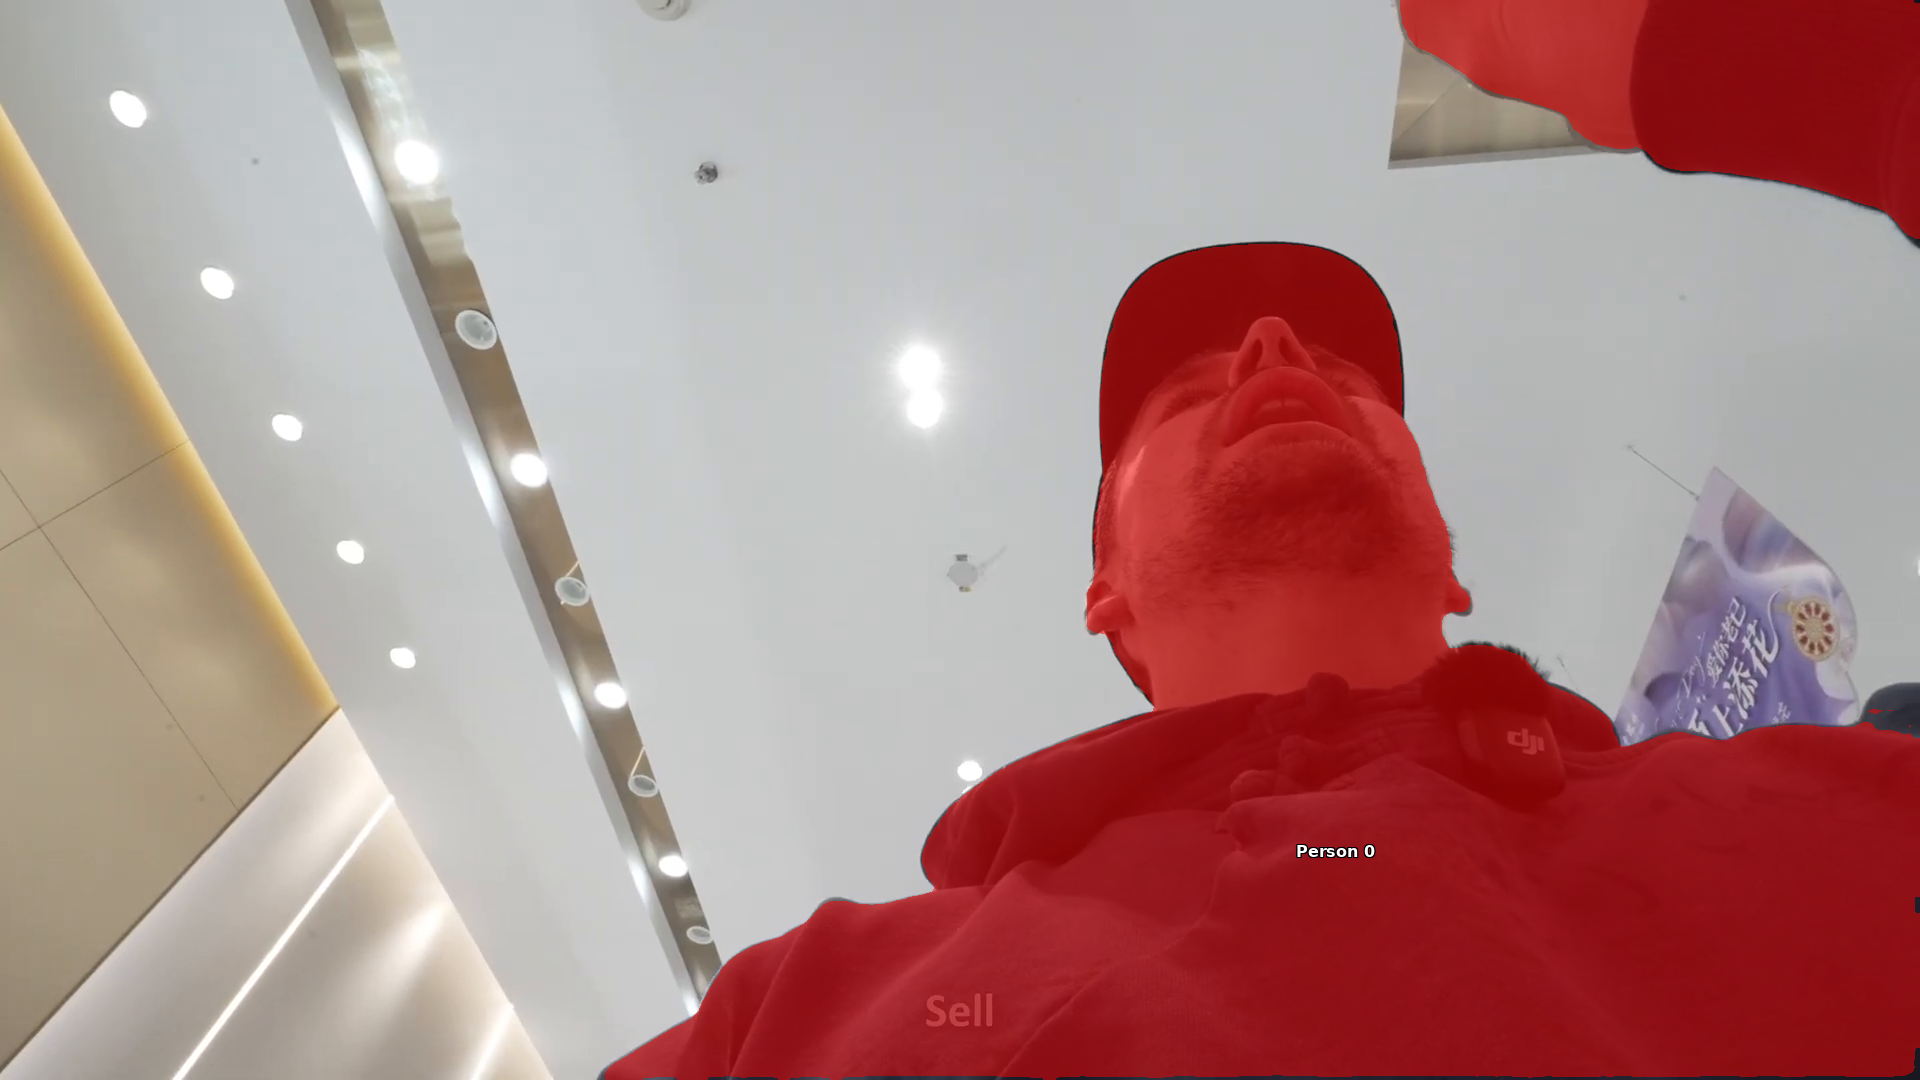

In [39]:
test_frame_idx = 0
test_global_frame_index = frame_numbers[test_frame_idx]

last_frame_img = frame_batch[test_frame_idx]
last_sam_output = outputs[test_global_frame_index]
last_sam_masks = last_sam_output.masks
object_ids = last_sam_output.out_obj_ids
visualize_segmentations(last_frame_img, last_sam_masks, labels=[f"Person {object_ids[0]}"])